$$
\mathbb{E}_{\text{val}}
\left[
|\nabla \log \hat f|^2
+
2 \Delta \log \hat f
\right].
$$

In [80]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *


manifold_type = 'S1'
manifold = get_manifold(manifold_type)

In [81]:
n_samples = 5000
sigma2 = .1

# prior param
num_modes = 3
tau2 = 0.05
G =  lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 
# G = lambda n: equator_sampler(manifold_type, n,  tau2)

# for empirical density estimation
rho = 1e-3

# for oracle approximation
num_oracle_samples = 10000
oracle_bandwidth = 0.01

# for crossvalidation
M_grid = np.arange(1,15,1)
# M_grid = np.arange(1,60,2)


In [82]:
Theta = multimodal_sampler(manifold_type, n_samples, tau2, num_modes)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

In [83]:
def select_M_by_scoreMatchingKFoldCV(manifold_type, X, M_grid,
                                     n_splits=5,
                                     return_scores=False,
                                     random_state=None,
                                     rho=1e-10,
                                     tryearlystop = False):
    """
    Select truncation level M by K-fold cross-validation
    using Hyvärinen score matching.
    """

    M_grid = np.array(M_grid)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    cv_scores = np.zeros_like(M_grid, dtype=float)

    for ixM, M in enumerate(M_grid):

        fold_scores = []

        for train_idx, val_idx in tqdm(
                kf.split(X),
                desc=f'Score-CV (M={M})',
                leave=False):

            X_train = X[train_idx]
            X_val = X[val_idx]

            # Evaluate f, grad f, Laplacian f on validation set
            _, hat_f, hat_grad_f, hat_lap_f = density_estimate(
                manifold_type,
                X_train,
                M,
                X_val,
                grad=True,
                laplacian=True
            )

            hat_f = np.clip(hat_f, rho, None)
            # # ||grad f||^2
            # if manifold_type == 'T2':
            #     grad_sq = np.sum(hat_grad_f**2, axis=(1,2))
            # else:
            grad_sq = np.sum(hat_grad_f**2, axis=1)

            grad_log_sq = grad_sq / (hat_f**2)
            lap_log = (hat_lap_f / hat_f) - (grad_sq / (hat_f**2))
            hyvarinen_vals = grad_log_sq + 2 * lap_log
            fold_scores.append(np.mean(hyvarinen_vals))

        cv_scores[ixM] = np.mean(fold_scores)

        # Early stopping (optional)
        
        if tryearlystop and M > 10 and ixM >= 5 and np.all(np.diff(cv_scores[ixM-5:ixM]) > 0):
            print(f"Early stopping at M={M}")
            cv_scores = cv_scores[:ixM+1]
            M_grid = M_grid[:ixM+1]
            break

    n = len(X)

    Mstar = {
        'cv': M_grid[np.argmin(cv_scores)],
        'AIC': M_grid[np.argmin(cv_scores + 2 * M_grid / n)],
        'BIC': M_grid[np.argmin(cv_scores + np.log(n) * M_grid / n)],
    }

    if return_scores:
        return Mstar, cv_scores
    else:
        return Mstar

In [84]:
Mstar, scores = select_M_by_scoreMatchingKFoldCV(manifold_type, X, M_grid,
                                     n_splits=5,
                                     return_scores=True,
                                     random_state=None,
                                     rho=1e-3, tryearlystop = False)

{'cv': 4, 'AIC': 4, 'BIC': 4}

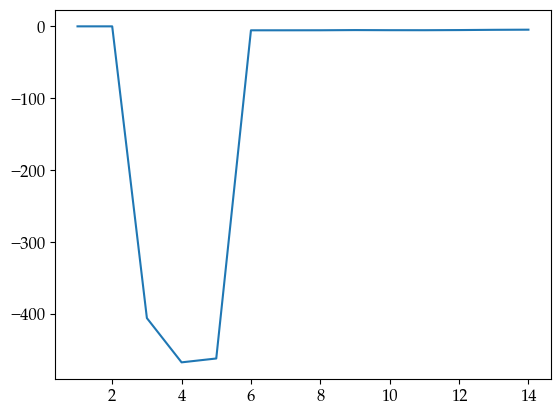

In [85]:
plt.plot(M_grid, scores)
Mstar

In [31]:
scores

array([ 1.70281854e-03,  3.00505049e-02, -1.02620140e+17, -1.65689130e+17])

In [88]:
Mstar, cvscores = select_M_by_DensityKFoldCV(manifold_type, X, M_grid, n_splits = 5, n_grid_samples = 1000, return_scores=True)

if True:
    M_grid_ = M_grid[:len(cvscores)]
    fig = plt.figure(figsize=(10, 4))
    plt.plot(M_grid_, cvscores, marker='o', label='LOOCV score', color='red')
    plt.axvline(Mstar['cv'], color='red', linestyle='--')
    plt.xlabel('M')
    plt.ylabel('Score')
    plt.title('Model selection by KFold CV | score matching')
    plt.legend()
    plt.show()

NameError: name 'select_M_by_DensityKFoldCV' is not defined

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
from tqdm import tqdm

def select_M_by_DensityKFoldCV(manifold_type, X, M_grid, 
                                n_splits=5,
                                n_grid_samples=1000, 
                                return_scores=False,
                                random_state=None):
    '''
    Select the degree M of the Legendre expansion by K-fold cross-validation.

    Parameters
    ----------
    manifold_type : str
    X : np.ndarray
    M_grid : list or np.ndarray
    n_splits : int, optional (default=5)
    n_grid_samples : int, optional
    return_scores : bool, optional
    random_state : int or None

    Returns
    -------
    dict (or tuple if return_scores=True)
    '''

    # manifold = get_manifold(manifold_type)
    # uniform_samples = manifold.random_uniform(n_grid_samples)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)


    cv_scores = np.zeros_like(M_grid, dtype=float)

    for ixM, M in enumerate(M_grid):

        fold_scores = []
        for train_idx, val_idx in tqdm(kf.split(X),desc=f'kfold (M={M})',leave=False):
            X_train = X[train_idx]
            X_val = X[val_idx]

            hat_f_square_integral = np.square(
                density_estimate(manifold_type, X_train, M, X_train, grad=False)[1]
                # density_estimate(manifold_type, X_train, M,uniform_samples, grad=False)[1]
                    ).mean()

            val_vals = density_estimate(manifold_type, X_train, M,X_val, grad=False)[1]

            fold_score = hat_f_square_integral - 2 * np.mean(val_vals)
            fold_scores.append(fold_score)

        cv_scores[ixM] = np.mean(fold_scores)

    Mstar = {
        'cv': M_grid[np.argmin(cv_scores)],
        'AIC': M_grid[np.argmin(cv_scores + 2 * M_grid / len(X))],
        'BIC': M_grid[np.argmin(cv_scores + np.log(len(X)) * M_grid / len(X))],
    }

    if return_scores:
        return Mstar, cv_scores
    else:
        return Mstar
    


def select_M_by_DensityLOOCV(manifold_type, X, M_grid,
                              n_grid_samples = 1000, 
                              return_scores = False):
    '''
    Select the degree M of the Legendre expansion by leave-one-out cross-validation.
    Parameters
    ----------
    manifold_type : str
    X : np.ndarray
    M_grid : list or np.ndarray
    penalty : str, optional (default 'none', possible 'AIC', 'BIC')
    n_grid_samples : int, optional
    return_scores : bool, optional
    Returns
    '''
    # manifold = get_manifold(manifold_type)
    # uniform_samples = manifold.random_uniform(n_grid_samples)

    idx = np.arange(len(X))

    cv_scores = np.zeros_like(M_grid, dtype=float)
    for ixM, M in enumerate(M_grid):
        # hat_f_square_integral = np.square(density_estimate(manifold_type, X, M, uniform_samples, grad = False)[1]).mean()
        hat_f_square_integral = np.square(density_estimate(manifold_type, X, M, X, grad = False)[1]).mean()

        loo_vals = [
            density_estimate(manifold_type, X[idx != i], M, np.array([X[i]]), grad = False)[1]
            for i in tqdm(idx, desc=f'loo (M={M})', position=0, leave=False)
        ]

        cv_scores[ixM] = hat_f_square_integral - 2 * np.mean(loo_vals)
    
    Mstar = {
        'cv' : M_grid[np.argmin(cv_scores)],
        'AIC' : M_grid[np.argmin(cv_scores + 2 * M_grid/len(X))],
        'BIC' : M_grid[np.argmin(cv_scores + np.log(len(X)) * M_grid/len(X))],
    }
    if return_scores:
        return Mstar, cv_scores
    else:
        return Mstar


In [ ]:

def select_M_by_ScoreMatchingLOOCV(manifold_type, X, M_grid, return_scores = False):
    '''
    Select the degree M of the Legendre expansion by leave-one-out cross-validation.
    Parameters
    ----------
    manifold_type : str
    X : np.ndarray
    M_grid : list or np.ndarray
    penalty : str, optional (default 'none', possible 'AIC', 'BIC')
    n_grid_samples : int, optional
    return_scores : bool, optional
    Returns
    '''
    manifold = get_manifold(manifold_type)

    idx = np.arange(len(X))

    cv_scores = np.zeros_like(M_grid, dtype=float)
    for ixM, M in enumerate(M_grid):
        for i in tqdm(idx, desc=f'loo (M={M})', position=0, leave=False):
            _, _f, _gradf = density_estimate(
                manifold_type, X[idx != i], M, np.array([X[i]]), grad=True
            )
            score = _gradf[0] /( _f[0] + 1e-2)
            cv_scores += np.dot(score,score)

        # Average over n
        cv_scores[ixM] /= len(X)
        
    Mstar = {
        'cv' : M_grid[np.argmin(cv_scores)],
        'AIC' : M_grid[np.argmin(cv_scores + 2 * M_grid/len(X))],
        'BIC' : M_grid[np.argmin(cv_scores + np.log(len(X)) * M_grid/len(X))],
    }
    if return_scores:
        return Mstar, cv_scores
    else:
        return Mstar


In [ ]:
import numpy as np
from tqdm import tqdm

def select_M_by_SSM_LOOCV(manifold_type, X, M_grid, 
                          n_directions=5, h=1e-4,
                          return_scores=False):

    n, d = X.shape
    idx = np.arange(n)
    cv_scores = np.zeros(len(M_grid))

    for ixM, M in enumerate(M_grid):

        total_loss = 0.0

        for i in tqdm(idx, desc=f'SSM-LOO (M={M})', leave=False):

            X_train = X[idx != i]
            x = X[i:i+1]

            # Evaluate density and gradient at x
            _, f, gradf = density_estimate(manifold_type, X_train, M, x, grad=True)

            f = f[0]
            gradf = gradf[0]

            if f <= 0:
                continue  # safety

            s = gradf / f  # score at x

            # Monte Carlo over random tangent directions
            point_loss = 0.0

            for _ in range(n_directions):

                # sample random direction in R^d
                v = np.random.randn(d)
                v /= np.linalg.norm(v)
                proj = np.dot(v, s)

                # small step along direction
                x_perturbed = x + h * v

                _, f2, gradf2 = density_estimate(manifold_type, X_train, M, x_perturbed, grad=True)

                f2 = f2[0]
                gradf2 = gradf2[0]

                if f2 <= 0:
                    continue

                s2 = gradf2 / f2

                directional_second = (np.dot(v, s2) - proj) / h

                point_loss += proj**2 + 2 * directional_second

            point_loss /= n_directions
            total_loss += point_loss

        cv_scores[ixM] = total_loss / n

    M_star = M_grid[np.argmin(cv_scores)]

    if return_scores:
        return M_star, cv_scores
    else:
        return M_star

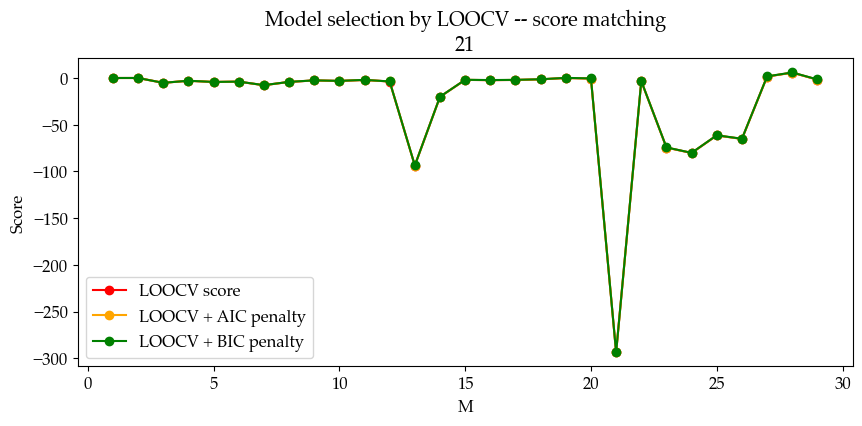

In [71]:
# Mstar, cvscores = select_M_by_SSM_LOOCV(manifold_type, X, M_grid, 
#                           n_directions=5, h=1e-4,
#                           return_scores=True); print(M)

if True:
    fig = plt.figure(figsize=(10, 4))
    plt.plot(M_grid, cvscores, marker='o', label='LOOCV score', color='red')
    plt.plot(M_grid, cvscores + 2 * M_grid/len(X), marker='o', label='LOOCV + AIC penalty', color='orange')
    plt.plot(M_grid, cvscores + np.log(len(X)) * M_grid/len(X), marker='o', label='LOOCV + BIC penalty', color='green')
    # plt.axvline(Mstar['cv'], color='red', linestyle='--')
    # plt.axvline(Mstar['AIC'], color='orange', linestyle='--')
    # plt.axvline(Mstar['BIC'], color='green', linestyle='--')
    plt.xlabel('M')
    plt.ylabel('Score')
    plt.title('Model selection by LOOCV -- score matching\n{}'.format(Mstar))
    plt.legend()
    plt.show()

In [76]:
def select_M_by_DensityLOOCV(
    manifold_type,
    X,
    M_grid,
    n_grid_samples=5000,
    cv_gradient=True,
    alpha=1.0,
    return_scores=False):
    
    manifold = get_manifold(manifold_type)
    idx = np.arange(len(X))
    U = manifold.random_uniform(n_grid_samples)

    cv_scores = np.zeros(len(M_grid))

    for j, M in enumerate(M_grid):

        # ----- full estimator on grid -----
        out_full = density_estimate(manifold_type, X, M, U, grad=cv_gradient)
        f_full = out_full[1]
        cv = np.mean(f_full**2)

        if cv_gradient:
            g_full = out_full[2]
            cv += alpha * np.mean(np.sum(g_full**2, axis=-1))

        # ----- LOO terms -----
        loo = [
            density_estimate(
                manifold_type,
                X[idx != i],
                M,
                X[i:i+1],
                grad=cv_gradient,
            )
            for i in idx
        ]

        cv -= 2 * np.mean([o[1] for o in loo])

        if cv_gradient:
            cv -= 2 * alpha * np.mean(
                [np.sum(o[2]**2) for o in loo]
            )

        cv_scores[j] = cv

    n = len(X)
    penalties = {
        "cv": cv_scores,
        "AIC": cv_scores + 2 * M_grid / n,
        "BIC": cv_scores + np.log(n) * M_grid / n,
    }

    Mstar = {k: M_grid[np.argmin(v)] for k, v in penalties.items()}
    return (Mstar, cv_scores) if return_scores else Mstar

In [ ]:
M = best_M

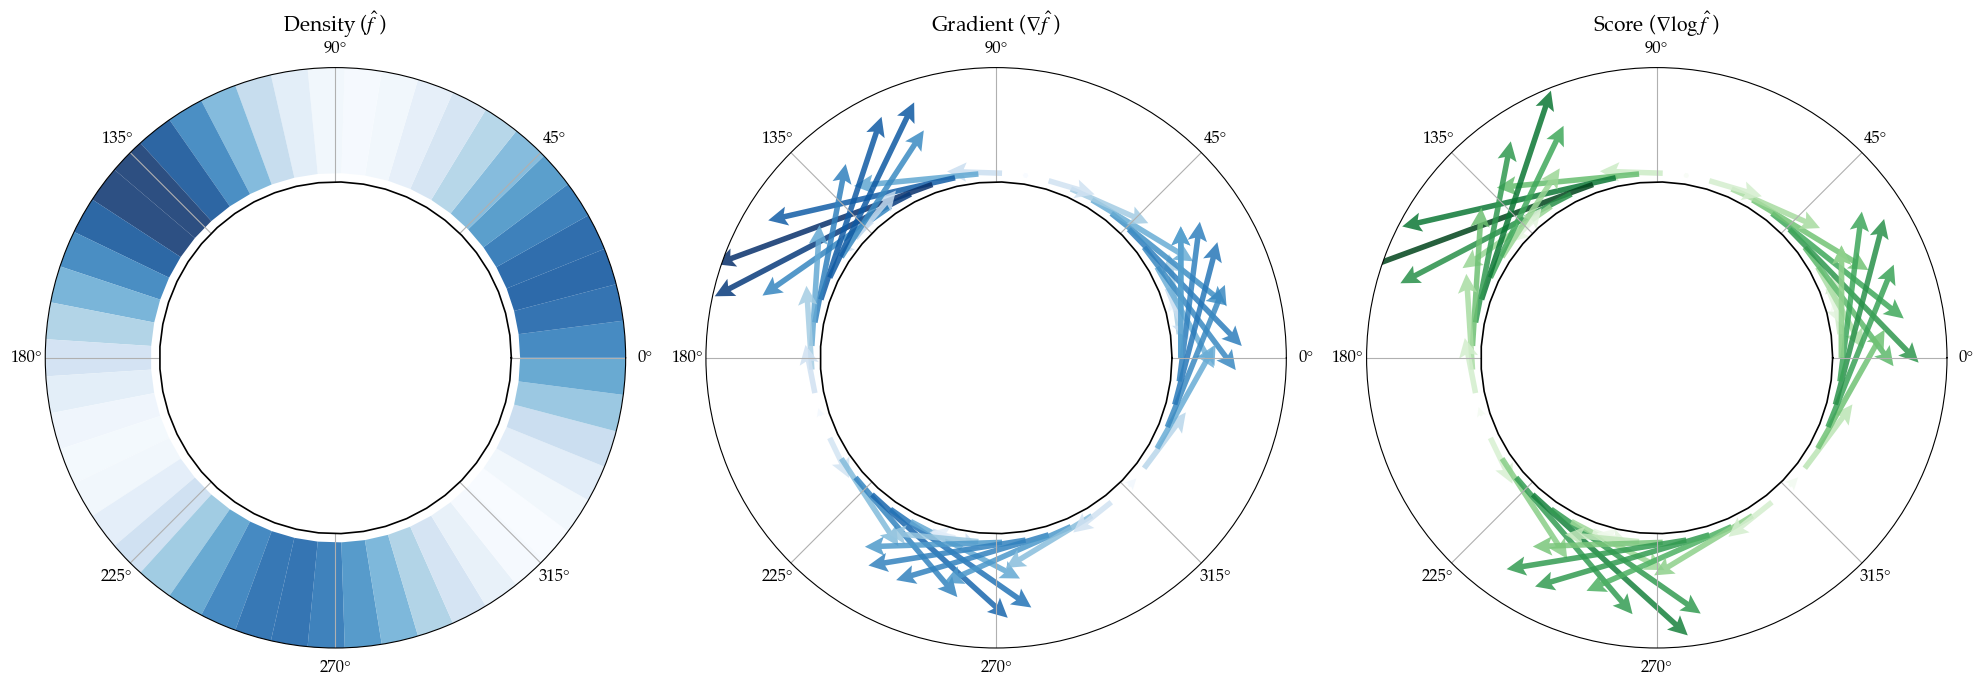

loo (M=20):  34%|███▍      | 342/1000 [00:19<00:00, 681.95it/s]

In [10]:
if True:
    f_scale = 0.3
    bottom = 0.105
    top = .5
    disk_r = 0.1

    fig, axs = plt.subplots(1, 3, figsize=(20, 10), subplot_kw={'polar': True})
    grid_I = np.linspace(0, 2*np.pi, 50)
    grid = np.stack([np.cos(grid_I), np.sin(grid_I)], axis=1)
    _, hat_f, hat_grad_f = density_estimate('S1', X, M, grid)
    # ---------- DENSITY ---------------------------------------------------------------------------
    hat_pos_f = np.maximum(hat_f, 0)
    normalised_hat_f = (hat_pos_f - hat_pos_f.min()) / (hat_pos_f.max() - hat_pos_f.min() + 1e-10)
    verts = [[
            (grid_I[i], bottom),
            # (grid_I[i], bottom + f_scale * hat_pos_f[i]), (grid_I[i+1], bottom + f_scale * hat_pos_f[i+1]),
            (grid_I[i],top), (grid_I[i+1], bottom + top),
            (grid_I[i+1], bottom)
        ] for i in range(len(grid_I) - 1)] # Create polygon vertices for each segment
    poly = PolyCollection(verts, facecolors=plt.colormaps['Blues'](normalised_hat_f[:-1]), 
                        alpha=0.85, edgecolors='none')
    axs[0].add_collection(poly)
    axs[0].set_title('Density ($\hat f$)', fontsize=15)
    # ---------- GRADIENT ---------------------------------------------------------------------------
    axs[1].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_grad_f[:, 0],          
        hat_grad_f[:, 1],          
        np.linalg.norm(hat_grad_f, axis=1),                 
        scale=4,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Blues',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs[1].set_title('Gradient ($\\nabla \hat f$)', fontsize=15)
    # ---------- SCORE ---------------------------------------------------------------------------
    hat_score = hat_grad_f /  np.maximum(hat_f.reshape(-1, 1), rho)
    axs[2].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_score[:, 0],          
        hat_score[:, 1],          
        np.linalg.norm(hat_score, axis=1),                 
        scale=7,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Greens',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs[2].set_title('Score ($\\nabla \log \hat f$)', fontsize=15)
    # -------------------------------------------------------------------------------------
    for ax in axs: 
        ax.set_ylim(0, bottom + f_scale*.2)  
        ax.set_yticks([])
        ax.bar(0, disk_r, width=2*np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
        ax.plot(grid_I, disk_r*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)
    plt.tight_layout()
    plt.show()

In [ ]:
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    
    for ixM, M in enumerate(M_grid):
        # 1. INTEGRAL TERM: \int \hat{f}^2 dx
        # For manifolds, we often approximate this by sampling points 
        # from the manifold or using a Monte Carlo approach.
        # If your manifold library has a 'volume' or 'integral' helper, use it.
        # Here, we'll assume a Monte Carlo approximation by sampling 'n_samples'
        n_mc_samples = 1000
        mc_points = manifold.random_uniform(n_mc_samples) # Sample from the manifold space
        
        # Estimate density at Monte Carlo points using training data
        _, dens_mc, _ = kernel_density_estimate(manifold_type, X_train, M, mc_points)
        integral_approx = np.mean(dens_mc**2) # This scales with manifold volume
        
        for ixrho, rho in enumerate(rho_grid):
            # 2. EVALUATION TERM: (2/n) * sum(f_train(X_test))
            # Evaluate the density of the TEST fold using parameters (M, rho)
            # based ONLY on the TRAINING fold.
            _, dens_test, _ = kernel_density_estimate(manifold_type, X_train, M, X_test, rho=rho)
            eval_term = 2.0 * np.mean(dens_test)
            
            # 3. LSCV Objective: Integral - 2 * Expectation
            # We want to MINIMIZE this value
            fold_score = integral_approx - eval_term
            cv_scores[ixM, ixrho] += fold_score / n_folds

# Find the indices of the minimum score
best_ixM, best_ixrho = np.unravel_index(np.argmin(cv_scores), cv_scores.shape)
print(f"Best M: {M_grid[best_ixM]}, Best rho: {rho_grid[best_ixrho]}")

In [ ]:
          
        # cv_scores[ixM, ixrho]= 

        # Not really for your setting.
        # scikit-learn's LOO helpers work with *estimators* that implement fit/predict/score,
        # and KDE in sklearn (KernelDensity) is Euclidean-only, not manifold-aware (S1 geodesic / your utils).

        # If you were in R^d and wanted sklearn-style LOO, you'd do something like:
        #   - use KernelDensity for log density
        #   - loop over LeaveOneOut splits
        # But for S1 with your `density_estimate(...)`, you need to do the masking / indexing approach.

        # Keep the LOO masking approach you already have, but fix it into a clean block:

        # (re)initialize if needed (cv_scores already exists in your notebook, so only do this if you want to reset)
       
# for train_idx, test_idx in kf.split(X):
#     X_train, X_test = X[train_idx], X[test_idx]
#     for ixM, M in enumerate(M_grid):
#         for ixrho, rho in enumerate(rho_grid):
#             0
            

In [ ]:
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True)
rho_grid =np.logspace(-1,-10, num=10)